# PAWS Dataset Comprehensive Analysis

This notebook provides a complete analysis of the PAWS (Paraphrase Adversaries from Word Scrambling) annotated dataset including:
- Dataset overview and exploration
- Label distribution analysis
- Feature statistics
- Data distribution visualizations
- Text length analysis
- Categorical feature analysis

## Section 1: Import Required Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# Configure visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Section 2: Load the Dataset

In [2]:
# Load the dataset
file_path = '../paws_annotated_data/paws_annotated_full.tsv'
df = pd.read_csv(file_path, sep='\t')

print("✓ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

✓ Dataset loaded successfully!
Shape: (53287, 12)

Columns: ['source', 'target', 'label', 'label_str', 'src_tokens', 'tgt_tokens', 'lexical_overlap', 'seq_similarity', 'length_ratio', 'length_label', 'style_label', 'combo_label']


## Section 3: Explore Dataset Overview

In [3]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"\nDataset Shape: {df.shape}")
print("\nColumn Names and Data Types:")
print(df.dtypes)

print("\n" + "="*60)
print("First 5 Rows:")
print("="*60)
df.head()

DATASET OVERVIEW

Dataset Shape: (53287, 12)

Column Names and Data Types:
source                 str
target                 str
label                int64
label_str              str
src_tokens           int64
tgt_tokens           int64
lexical_overlap    float64
seq_similarity     float64
length_ratio       float64
length_label           str
style_label            str
combo_label            str
dtype: object

First 5 Rows:


,source,target,label,label_str,src_tokens,tgt_tokens,lexical_overlap,seq_similarity,length_ratio,length_label,style_label,combo_label
0,In Paris in October 1560 he secretly met the...,In October 1560 he secretly met with the Engl...,0,not_paraphrase,24,26,0.7037,0.8471,1.0833,SAME,CONSERVATIVE,[SAME] [CONSERVATIVE]
1,The NBA season of 1975 -- 76 was the 30th seas...,The 1975 -- 76 season of the National Basketba...,1,paraphrase,16,17,0.7143,0.6778,1.0625,SAME,CREATIVE,[SAME] [CREATIVE]
2,There are also specific discussions public pr...,There are also public discussions profile spe...,0,not_paraphrase,11,11,0.9000,0.7052,1.0000,SAME,CREATIVE,[SAME] [CREATIVE]
3,When comparable rates of flow can be maintaine...,The results are high when comparable flow rate...,1,paraphrase,12,11,0.7692,0.5735,0.9167,SAME,CREATIVE,[SAME] [CREATIVE]
4,It is the seat of Zerendi District in Akmola R...,It is the seat of the district of Zerendi in A...,1,paraphrase,10,12,1.0000,0.7568,1.2000,LONG,CONSERVATIVE,[LONG] [CONSERVATIVE]


In [4]:
print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
df.info()


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 53287 entries, 0 to 53286
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source           53287 non-null  str    
 1   target           53287 non-null  str    
 2   label            53287 non-null  int64  
 3   label_str        53287 non-null  str    
 4   src_tokens       53287 non-null  int64  
 5   tgt_tokens       53287 non-null  int64  
 6   lexical_overlap  53287 non-null  float64
 7   seq_similarity   53287 non-null  float64
 8   length_ratio     53287 non-null  float64
 9   length_label     53287 non-null  str    
 10  style_label      53287 non-null  str    
 11  combo_label      53287 non-null  str    
dtypes: float64(3), int64(3), str(6)
memory usage: 18.6 MB


In [5]:
print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print("\nDataset Description:")
df.describe()


Missing Values:
No missing values found!

Dataset Description:


,label,src_tokens,tgt_tokens,lexical_overlap,seq_similarity,length_ratio
count,53287.000000,53287.000000,53287.000000,53287.000000,53287.000000,53287.000000
mean,0.441402,19.017828,19.013906,0.779540,0.810980,1.002307
std,0.496559,4.979467,4.964493,0.125342,0.130576,0.068716
min,0.000000,4.000000,4.000000,0.153800,0.111800,0.480000
25%,0.000000,15.000000,15.000000,0.692300,0.744500,0.958300
50%,0.000000,19.000000,19.000000,0.785700,0.836100,1.000000
75%,1.000000,23.000000,23.000000,0.869600,0.907800,1.043500
max,1.000000,35.000000,35.000000,1.000000,0.997300,4.000000


## Section 4: Identify Column Types

In [6]:
# Identify different column types
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
text_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in df.columns 
                    if df[col].dtype == 'object' 
                    and col not in text_cols 
                    and df[col].nunique() < 50]

print("Column Type Identification:")
print(f"  ✓ Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"  ✓ Text columns ({len(text_cols)}): {text_cols}")
print(f"  ✓ Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Column Type Identification:
  ✓ Numerical columns (6): ['label', 'src_tokens', 'tgt_tokens', 'lexical_overlap', 'seq_similarity', 'length_ratio']
  ✓ Text columns (6): ['source', 'target', 'label_str', 'length_label', 'style_label', 'combo_label']
  ✓ Categorical columns (0): []


## Section 5: Analyze Label Distribution

In [7]:
print("="*60)
print("LABEL DISTRIBUTION")
print("="*60)

label_counts = df['label'].value_counts().sort_index()
label_percentages = df['label'].value_counts(normalize=True).sort_index() * 100

print("\nLabel Counts:")
print(label_counts)

print("\nLabel Percentages:")
print(label_percentages)

LABEL DISTRIBUTION

Label Counts:
label
0    29766
1    23521
Name: count, dtype: int64

Label Percentages:
label
0    55.859778
1    44.140222
Name: proportion, dtype: float64


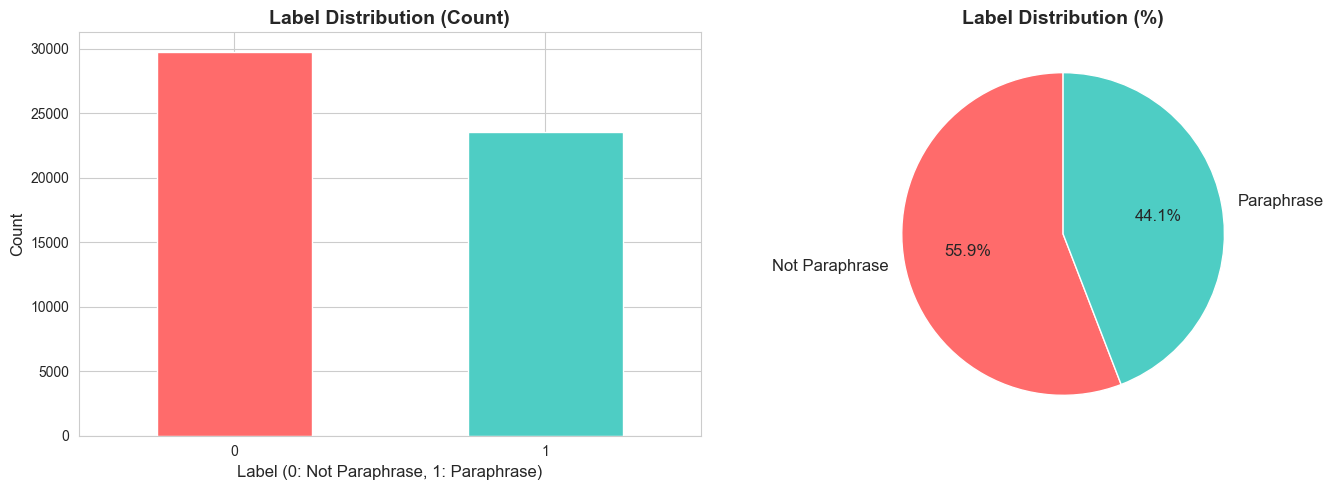

✓ Label distribution visualization complete!


In [8]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Label Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (0: Not Paraphrase, 1: Paraphrase)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
colors = ['#FF6B6B', '#4ECDC4']
axes[1].pie(label_counts, labels=['Not Paraphrase', 'Paraphrase'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Label Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Label distribution visualization complete!")

## Section 6: Analyze Numerical Features

In [9]:
print("="*60)
print("NUMERICAL FEATURE STATISTICS")
print("="*60)

if numerical_cols:
    print(f"\nNumerical Columns: {numerical_cols}")
    
    print("\n=== Feature Statistics by Label ===")
    for col in numerical_cols:
        print(f"\n{col}:")
        print(df.groupby('label')[col].describe())
else:
    print("No numerical columns found.")

NUMERICAL FEATURE STATISTICS

Numerical Columns: ['label', 'src_tokens', 'tgt_tokens', 'lexical_overlap', 'seq_similarity', 'length_ratio']

=== Feature Statistics by Label ===

label:
         count  mean  std  min  25%  50%  75%  max
label                                             
0      29766.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
1      23521.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0

src_tokens:
         count       mean       std  min   25%   50%   75%   max
label                                                           
0      29766.0  19.097023  5.001864  4.0  15.0  19.0  23.0  35.0
1      23521.0  18.917606  4.949268  4.0  15.0  19.0  23.0  35.0

tgt_tokens:
         count       mean       std  min   25%   50%   75%   max
label                                                           
0      29766.0  19.101357  4.988625  4.0  15.0  19.0  23.0  35.0
1      23521.0  18.903235  4.931666  4.0  15.0  19.0  23.0  35.0

lexical_overlap:
         count      mean       std     min     

In [10]:
print("\n=== Overall Feature Statistics ===")
if numerical_cols:
    print(df[numerical_cols].describe())
else:
    print("No numerical columns to display.")


=== Overall Feature Statistics ===
              label    src_tokens    tgt_tokens  lexical_overlap  \
count  53287.000000  53287.000000  53287.000000     53287.000000   
mean       0.441402     19.017828     19.013906         0.779540   
std        0.496559      4.979467      4.964493         0.125342   
min        0.000000      4.000000      4.000000         0.153800   
25%        0.000000     15.000000     15.000000         0.692300   
50%        0.000000     19.000000     19.000000         0.785700   
75%        1.000000     23.000000     23.000000         0.869600   
max        1.000000     35.000000     35.000000         1.000000   

       seq_similarity  length_ratio  
count    53287.000000  53287.000000  
mean         0.810980      1.002307  
std          0.130576      0.068716  
min          0.111800      0.480000  
25%          0.744500      0.958300  
50%          0.836100      1.000000  
75%          0.907800      1.043500  
max          0.997300      4.000000  


## Section 7: Visualize Data Distributions - Histograms

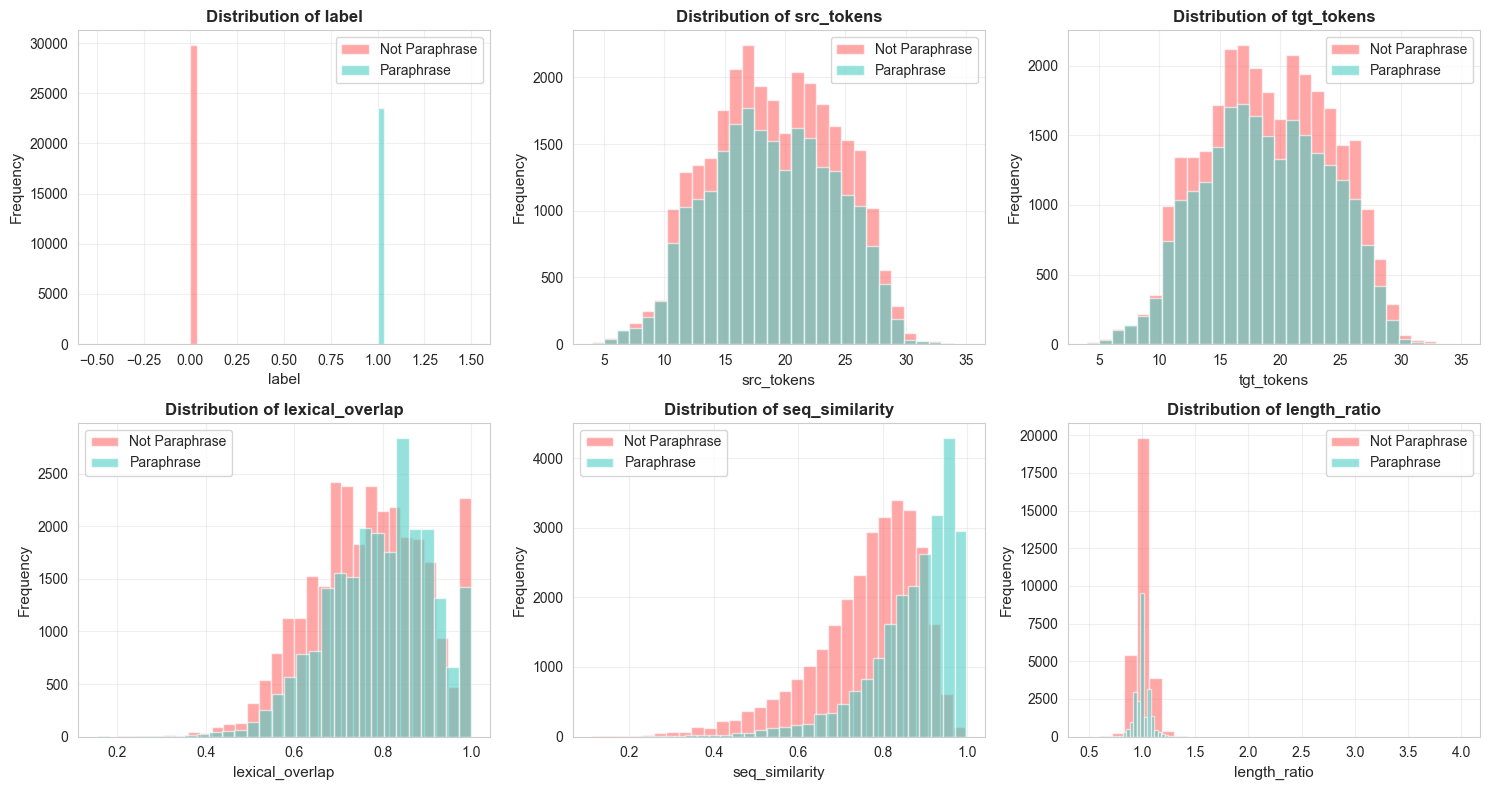

✓ Histogram visualization complete!


In [11]:
if numerical_cols:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        axes[idx].hist(df[df['label'] == 0][col], bins=30, alpha=0.6,
                      label='Not Paraphrase', color='#FF6B6B')
        axes[idx].hist(df[df['label'] == 1][col], bins=30, alpha=0.6,
                      label='Paraphrase', color='#4ECDC4')
        axes[idx].set_xlabel(col, fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
    
    # Remove extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
    print("✓ Histogram visualization complete!")
else:
    print("No numerical columns to visualize.")

## Section 8: Visualize Data Distributions - Box Plots

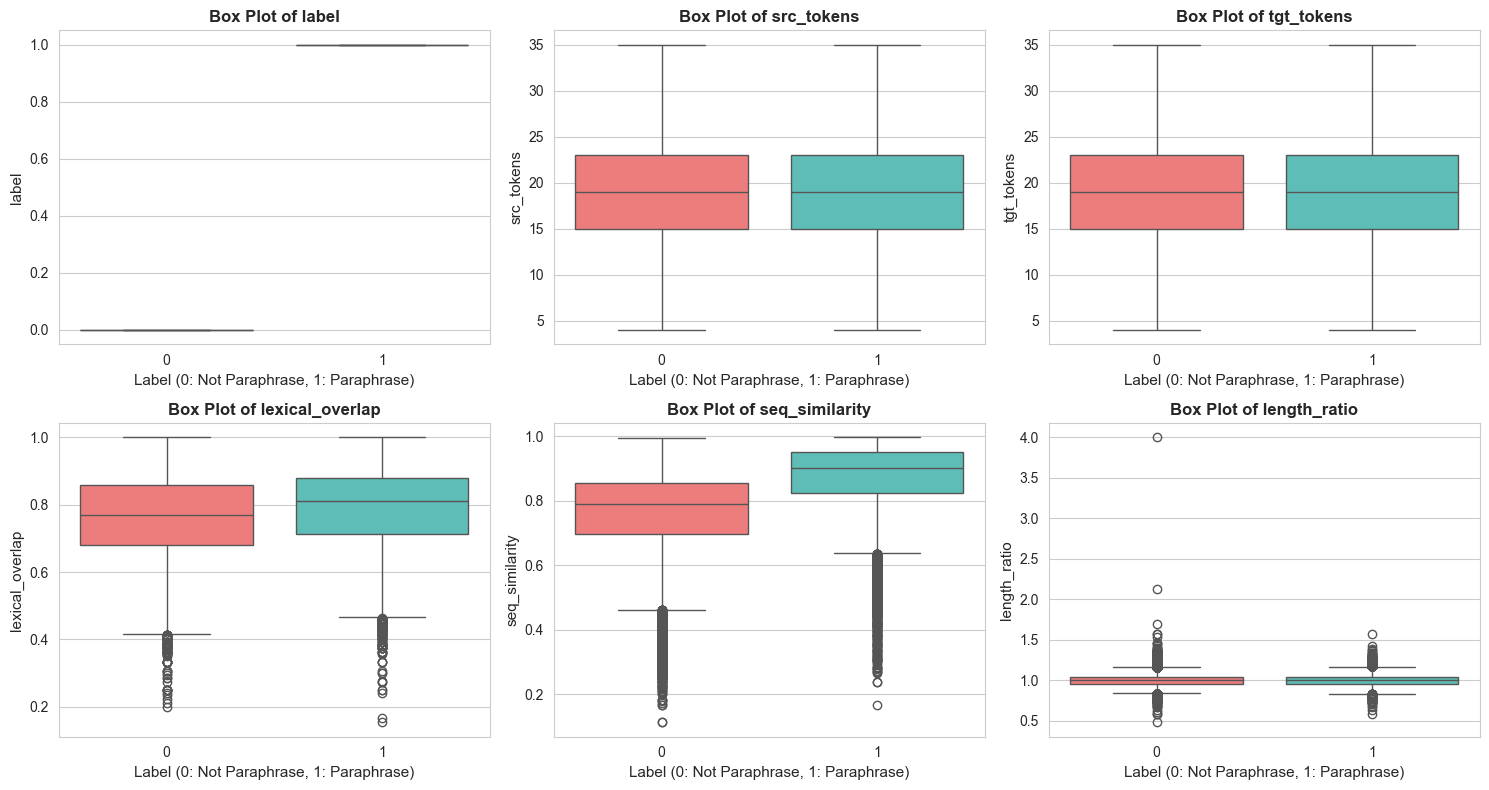

✓ Box plot visualization complete!


In [12]:
if numerical_cols:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        sns.boxplot(data=df, x='label', y=col, ax=axes[idx],
                   palette=['#FF6B6B', '#4ECDC4'])
        axes[idx].set_xlabel('Label (0: Not Paraphrase, 1: Paraphrase)', fontsize=11)
        axes[idx].set_ylabel(col, fontsize=11)
        axes[idx].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    
    # Remove extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
    print("✓ Box plot visualization complete!")
else:
    print("No numerical columns to visualize.")

## Section 9: Analyze Text Lengths

In [13]:
print("="*60)
print("TEXT LENGTH ANALYSIS")
print("="*60)

if text_cols:
    print(f"\nText Columns: {text_cols}")
    
    # Calculate text lengths
    for col in text_cols:
        if col != 'label':
            df[f'{col}_length'] = df[col].astype(str).str.len()
            df[f'{col}_tokens'] = df[col].astype(str).str.split().str.len()
    
    # Get length columns
    length_cols = [col for col in df.columns if col.endswith('_length')]
    token_cols = [col for col in df.columns if col.endswith('_tokens')]
    
    if length_cols:
        print("\nText Length Statistics:")
        print(df[length_cols].describe())
    
    if token_cols:
        print("\nToken Count Statistics:")
        print(df[token_cols].describe())
else:
    print("No text columns found.")

TEXT LENGTH ANALYSIS

Text Columns: ['source', 'target', 'label_str', 'length_label', 'style_label', 'combo_label']

Text Length Statistics:
       source_length  target_length  label_str_length  length_label_length  \
count   53287.000000   53287.000000      53287.000000         53287.000000   
mean      111.213917     111.182390         12.234391             4.014882   
std        30.395203      30.353328          1.986236             0.121081   
min        23.000000      23.000000         10.000000             4.000000   
25%        89.000000      89.000000         10.000000             4.000000   
50%       111.000000     111.000000         14.000000             4.000000   
75%       134.000000     134.000000         14.000000             4.000000   
max       220.000000     221.000000         14.000000             5.000000   

       style_label_length  combo_label_length  
count        53287.000000        53287.000000  
mean            10.963950           19.978832  
std         

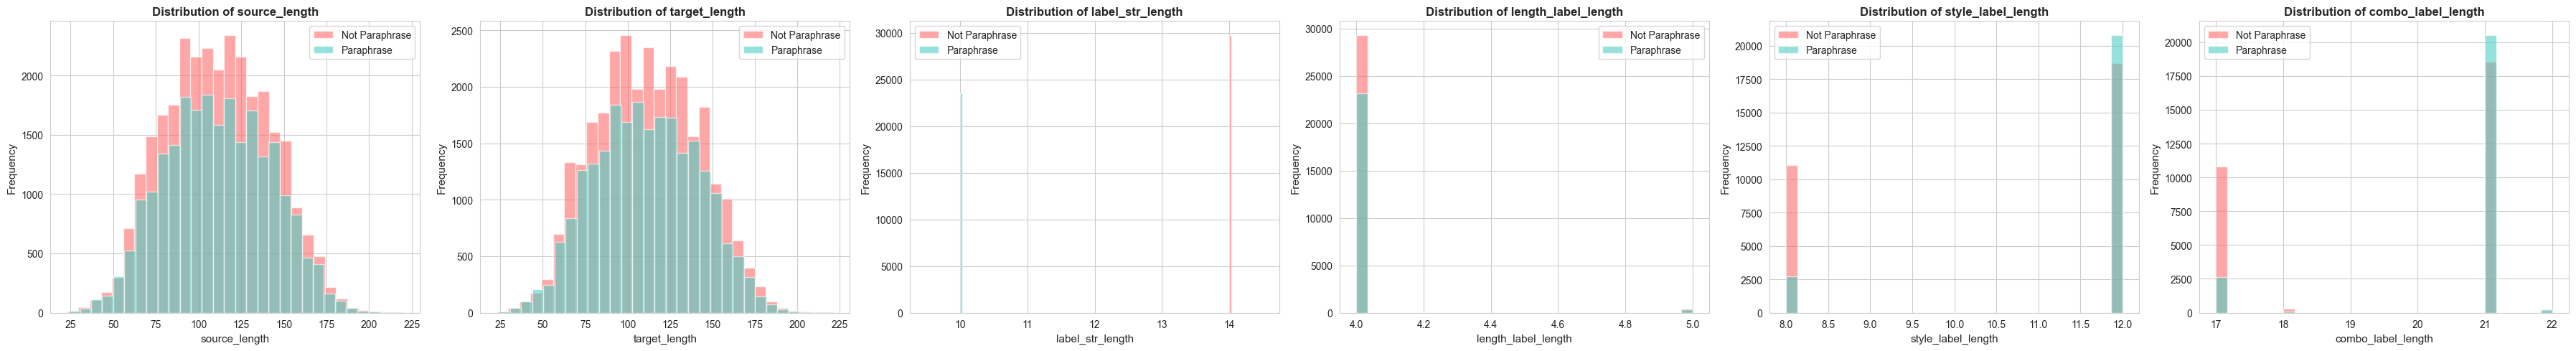

✓ Text length visualization complete!


In [14]:
# Visualize text lengths
length_cols = [col for col in df.columns if col.endswith('_length')]

if length_cols:
    fig, axes = plt.subplots(1, len(length_cols), figsize=(6 * len(length_cols), 5))
    if len(length_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(length_cols):
        axes[idx].hist(df[df['label'] == 0][col], bins=30, alpha=0.6,
                      label='Not Paraphrase', color='#FF6B6B')
        axes[idx].hist(df[df['label'] == 1][col], bins=30, alpha=0.6,
                      label='Paraphrase', color='#4ECDC4')
        axes[idx].set_xlabel(col, fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()
    print("✓ Text length visualization complete!")
else:
    print("No text length columns to visualize.")

## Section 10: Analyze Categorical Features

In [15]:
print("="*60)
print("CATEGORICAL FEATURE ANALYSIS")
print("="*60)

# Identify categorical columns
categorical_cols = [col for col in df.columns 
                   if df[col].dtype == 'object' 
                   and col not in text_cols 
                   and df[col].nunique() < 50]

if categorical_cols:
    print(f"\nCategorical Columns: {categorical_cols}")
    
    # Print statistics
    for col in categorical_cols:
        print(f"\n=== {col} ===")
        print(f"Unique Values: {df[col].nunique()}")
        print("\nValue Counts:")
        print(df[col].value_counts())
        
        print("\nCrosstab with Label:")
        crosstab = pd.crosstab(df[col], df['label'], margins=True)
        print(crosstab)
else:
    print("\nNo categorical columns with < 50 unique values found.")

CATEGORICAL FEATURE ANALYSIS

No categorical columns with < 50 unique values found.


In [16]:
# Visualize categorical features
if categorical_cols:
    n_cols = min(3, len(categorical_cols))
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if len(categorical_cols) > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        crosstab_data = pd.crosstab(df[col], df['label'])
        crosstab_data.plot(kind='bar', ax=axes[idx], color=['#FF6B6B', '#4ECDC4'])
        axes[idx].set_title(f'{col} by Label', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=11)
        axes[idx].set_ylabel('Count', fontsize=11)
        axes[idx].legend(['Not Paraphrase', 'Paraphrase'], loc='upper right')
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Remove extra subplots
    for idx in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
    print("✓ Categorical feature visualization complete!")
else:
    print("No categorical features to visualize.")

No categorical features to visualize.


## Section 11: Summary Report

In [17]:
print("\n" + "="*80)
print("PAWS DATASET COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print("\n1. DATASET OVERVIEW")
print("-"*80)
print(f"   Total Samples: {len(df)}")
print(f"   Number of Features: {len(df.columns)}")
print(f"   Columns: {list(df.columns)}")

print("\n2. LABEL DISTRIBUTION")
print("-"*80)
label_counts = df['label'].value_counts().sort_index()
label_percentages = df['label'].value_counts(normalize=True).sort_index() * 100
print(f"   Not Paraphrase (0): {label_counts[0]} ({label_percentages[0]:.2f}%)")
print(f"   Paraphrase (1): {label_counts[1]} ({label_percentages[1]:.2f}%)")

print("\n3. COLUMN TYPES")
print("-"*80)
print(f"   Numerical Features: {len(numerical_cols)} {numerical_cols}")
print(f"   Text Features: {len(text_cols)} {text_cols}")
print(f"   Categorical Features: {len(categorical_cols)} {categorical_cols}")

print("\n4. DATA QUALITY")
print("-"*80)
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("   ✓ No missing values found!")
else:
    print(f"   Missing Values: {missing_count}")
    print(df.isnull().sum())

print("\n" + "="*80)
print("✓ ANALYSIS COMPLETE!")
print("="*80)


PAWS DATASET COMPREHENSIVE ANALYSIS SUMMARY

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
   Total Samples: 53287
   Number of Features: 24
   Columns: ['source', 'target', 'label', 'label_str', 'src_tokens', 'tgt_tokens', 'lexical_overlap', 'seq_similarity', 'length_ratio', 'length_label', 'style_label', 'combo_label', 'source_length', 'source_tokens', 'target_length', 'target_tokens', 'label_str_length', 'label_str_tokens', 'length_label_length', 'length_label_tokens', 'style_label_length', 'style_label_tokens', 'combo_label_length', 'combo_label_tokens']

2. LABEL DISTRIBUTION
--------------------------------------------------------------------------------
   Not Paraphrase (0): 29766 (55.86%)
   Paraphrase (1): 23521 (44.14%)

3. COLUMN TYPES
--------------------------------------------------------------------------------
   Numerical Features: 6 ['label', 'src_tokens', 'tgt_tokens', 'lexical_overlap', 'seq_similarity', 'leng

In [18]:
print("="*80)
print("DETAILED LABEL ANALYSIS: style_label and length_label")
print("="*80)

# Check for style_label
if 'style_label' in df.columns:
    print("\n✓ style_label Column Found")
    print(f"  Unique Values: {df['style_label'].nunique()}")
    print(f"  Values: {sorted(df['style_label'].unique().tolist())}")
    print("\n  Distribution:")
    print(df['style_label'].value_counts())
else:
    print("\n✗ style_label column NOT found in dataset")
    print(f"  Available columns: {list(df.columns)}")

# Check for length_label
if 'length_label' in df.columns:
    print("\n" + "="*80)
    print("\n✓ length_label Column Found")
    print(f"  Unique Values: {df['length_label'].nunique()}")
    print(f"  Values: {sorted(df['length_label'].unique().tolist())}")
    print("\n  Distribution:")
    print(df['length_label'].value_counts())
else:
    print("\n✗ length_label column NOT found in dataset")

# Cross-tabulation analysis
if 'style_label' in df.columns and 'length_label' in df.columns:
    print("\n" + "="*80)
    print("\nCross-tabulation: style_label × length_label")
    print("="*80)
    crosstab = pd.crosstab(df['style_label'], df['length_label'], margins=True)
    print(crosstab)


DETAILED LABEL ANALYSIS: style_label and length_label

✓ style_label Column Found
  Unique Values: 2
  Values: ['CONSERVATIVE', 'CREATIVE']

  Distribution:
style_label
CONSERVATIVE    39485
CREATIVE        13802
Name: count, dtype: int64


✓ length_label Column Found
  Unique Values: 3
  Values: ['LONG', 'SAME', 'SHORT']

  Distribution:
length_label
SAME     51063
LONG      1431
SHORT      793
Name: count, dtype: int64


Cross-tabulation: style_label × length_label
length_label  LONG   SAME  SHORT    All
style_label                            
CONSERVATIVE   784  38275    426  39485
CREATIVE       647  12788    367  13802
All           1431  51063    793  53287


## Section 13: Create Balanced Dataset (13k Creative + 13k Conservative)

Extract approximately 13k CREATIVE and 13k CONSERVATIVE records, with balanced paraphrase/non-paraphrase split within each style.

In [21]:
# Load the full PAWS annotated dataset
full_df = pd.read_csv("../paws_annotated_data/paws_annotated_full.tsv", sep="\t")
print(f"Full dataset shape: {full_df.shape}")
print(f"\nOriginal style distribution:\n{full_df['style_label'].value_counts()}")
print(f"\nOriginal label distribution:\n{full_df['label'].value_counts()}")

# Target: 13k CREATIVE + 13k CONSERVATIVE = 26k total
# Within each style: ~6.5k paraphrase + ~6.5k non-paraphrase

target_per_style = 13000
target_per_label_per_style = target_per_style // 2  # ~6500 each

# Separate by style and label
datasets_by_style_label = {}
for style in ['CREATIVE', 'CONSERVATIVE']:
    for label in [0, 1]:
        mask = (full_df['style_label'] == style) & (full_df['label'] == label)
        datasets_by_style_label[(style, label)] = full_df[mask].copy()

# Sample from each group
balanced_records = []
for (style, label), subset in datasets_by_style_label.items():
    count = len(subset)
    target = min(target_per_label_per_style, count)
    sampled = subset.sample(n=target, random_state=42)
    balanced_records.append(sampled)
    label_name = "Paraphrase" if label == 1 else "Non-paraphrase"
    print(f"\n{style} - {label_name}:")
    print(f"  Available: {count} | Sampled: {target}")

# Combine all sampled records
balanced_full_df = pd.concat(balanced_records, ignore_index=True)
print(f"\n" + "="*80)
print(f"Final balanced dataset shape: {balanced_full_df.shape}")
print(f"\nFinal style distribution:")
print(balanced_full_df['style_label'].value_counts())
print(f"\nFinal label distribution:")
print(balanced_full_df['label'].value_counts())

# Cross-tabulation: style × label
print(f"\nCross-tabulation: style_label × label")
print("="*80)
crosstab_balanced = pd.crosstab(balanced_full_df['style_label'], balanced_full_df['label'], margins=True)
crosstab_balanced.index = crosstab_balanced.index.map({
    'CREATIVE': 'CREATIVE',
    'CONSERVATIVE': 'CONSERVATIVE',
    'All': 'All'
})
crosstab_balanced.columns = crosstab_balanced.columns.map({
    0: 'Non-Paraphrase (0)',
    1: 'Paraphrase (1)',
    'All': 'All'
})
print(crosstab_balanced)

# Save the balanced dataset
output_path = "../paws_annotated_data/paws_balanced_13k_per_style.tsv"
balanced_full_df.to_csv(output_path, sep="\t", index=False)
print(f"\n✓ Balanced dataset saved to: {output_path}")

Full dataset shape: (53287, 12)

Original style distribution:
style_label
CONSERVATIVE    39485
CREATIVE        13802
Name: count, dtype: int64

Original label distribution:
label
0    29766
1    23521
Name: count, dtype: int64

CREATIVE - Non-paraphrase:
  Available: 11074 | Sampled: 6500

CREATIVE - Paraphrase:
  Available: 2728 | Sampled: 2728

CONSERVATIVE - Non-paraphrase:
  Available: 18692 | Sampled: 6500

CONSERVATIVE - Paraphrase:
  Available: 20793 | Sampled: 6500

Final balanced dataset shape: (22228, 12)

Final style distribution:
style_label
CONSERVATIVE    13000
CREATIVE         9228
Name: count, dtype: int64

Final label distribution:
label
0    13000
1     9228
Name: count, dtype: int64

Cross-tabulation: style_label × label
label         Non-Paraphrase (0)  Paraphrase (1)    All
style_label                                            
CONSERVATIVE                6500            6500  13000
CREATIVE                    6500            2728   9228
All                      

## Section 14: Create Stratified Train/Validation/Test Splits

Create stratified train/val/test splits from the balanced dataset to maintain label and style distribution:
- Training: 17k records (~65%)
- Validation: 3k records (~11.5%)
- Test: Remaining records (~23.5%)

In [23]:
from sklearn.model_selection import train_test_split

print(f"Total dataset size: {len(balanced_full_df)}")
print(f"\nTarget split sizes:")
print(f"  Training: 17,000 (65%)")
print(f"  Validation: 3,000 (11.5%)")
print(f"  Test: ~{len(balanced_full_df) - 17000 - 3000} ({100 * (len(balanced_full_df) - 17000 - 3000) / len(balanced_full_df):.1f}%)")

# Create a stratification key combining label and style_label
balanced_full_df['strat_key'] = balanced_full_df['label'].astype(str) + '_' + balanced_full_df['style_label']

# First split: train (17k) vs. (val + test)
train_df, temp_df = train_test_split(
    balanced_full_df,
    train_size=17000,
    random_state=42,
    stratify=balanced_full_df['strat_key']
)

# Second split: val (3k) vs. test (remaining)
val_df, test_df = train_test_split(
    temp_df,
    train_size=3000,
    random_state=42,
    stratify=temp_df['strat_key']
)

# Remove stratification key
train_df = train_df.drop('strat_key', axis=1)
val_df = val_df.drop('strat_key', axis=1)
test_df = test_df.drop('strat_key', axis=1)

print(f"\n" + "="*80)
print("FINAL SPLIT SIZES")
print("="*80)
print(f"Training set: {len(train_df)} records")
print(f"Validation set: {len(val_df)} records")
print(f"Test set: {len(test_df)} records")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} records")

# Verify stratification: label distribution in each split
print(f"\n" + "="*80)
print("LABEL DISTRIBUTION ACROSS SPLITS")
print("="*80)
for split_name, split_data in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    label_counts = split_data['label'].value_counts()
    label_pct = split_data['label'].value_counts(normalize=True) * 100
    print(f"\n{split_name}:")
    print(f"  Non-paraphrase (0): {label_counts.get(0, 0):5d} ({label_pct.get(0, 0):5.1f}%)")
    print(f"  Paraphrase (1):     {label_counts.get(1, 0):5d} ({label_pct.get(1, 0):5.1f}%)")

# Verify style distribution in each split
print(f"\n" + "="*80)
print("STYLE DISTRIBUTION ACROSS SPLITS")
print("="*80)
for split_name, split_data in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    style_counts = split_data['style_label'].value_counts()
    style_pct = split_data['style_label'].value_counts(normalize=True) * 100
    print(f"\n{split_name}:")
    print(f"  CREATIVE:      {style_counts.get('CREATIVE', 0):5d} ({style_pct.get('CREATIVE', 0):5.1f}%)")
    print(f"  CONSERVATIVE:  {style_counts.get('CONSERVATIVE', 0):5d} ({style_pct.get('CONSERVATIVE', 0):5.1f}%)")

# Cross-tabulation for each split
print(f"\n" + "="*80)
print("CROSS-TABULATION: STYLE × LABEL FOR EACH SPLIT")
print("="*80)
for split_name, split_data in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{split_name}:")
    crosstab_split = pd.crosstab(split_data['style_label'], split_data['label'], margins=True)
    crosstab_split.columns = crosstab_split.columns.map({
        0: 'Non-Para',
        1: 'Paraphrase',
        'All': 'Total'
    })
    print(crosstab_split)

# Save the splits
output_dir = "../data/classification_splits"
import os
os.makedirs(output_dir, exist_ok=True)

train_path = f"{output_dir}/train.csv"
val_path = f"{output_dir}/val.csv"
test_path = f"{output_dir}/test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"\n" + "="*80)
print("SAVED SPLITS")
print("="*80)
print(f"✓ Training set: {train_path}")
print(f"✓ Validation set: {val_path}")
print(f"✓ Test set: {test_path}")

Total dataset size: 22228

Target split sizes:
  Training: 17,000 (65%)
  Validation: 3,000 (11.5%)
  Test: ~2228 (10.0%)

FINAL SPLIT SIZES
Training set: 17000 records
Validation set: 3000 records
Test set: 2228 records
Total: 22228 records

LABEL DISTRIBUTION ACROSS SPLITS

Train:
  Non-paraphrase (0):  9942 ( 58.5%)
  Paraphrase (1):      7058 ( 41.5%)

Val:
  Non-paraphrase (0):  1755 ( 58.5%)
  Paraphrase (1):      1245 ( 41.5%)

Test:
  Non-paraphrase (0):  1303 ( 58.5%)
  Paraphrase (1):       925 ( 41.5%)

STYLE DISTRIBUTION ACROSS SPLITS

Train:
  CREATIVE:       7058 ( 41.5%)
  CONSERVATIVE:   9942 ( 58.5%)

Val:
  CREATIVE:       1245 ( 41.5%)
  CONSERVATIVE:   1755 ( 58.5%)

Test:
  CREATIVE:        925 ( 41.5%)
  CONSERVATIVE:   1303 ( 58.5%)

CROSS-TABULATION: STYLE × LABEL FOR EACH SPLIT

Train:
label         Non-Para  Paraphrase  Total
style_label                              
CONSERVATIVE      4971        4971   9942
CREATIVE          4971        2087   7058
All       